/tmp/ipykernel_5250/2704120951.py:26: RuntimeWarning: overflow encountered in scalar add
  c = 255 / np.log(1 + np.max(gray))
/tmp/ipykernel_5250/2704120951.py:26: RuntimeWarning: divide by zero encountered in log
  c = 255 / np.log(1 + np.max(gray))
/tmp/ipykernel_5250/2704120951.py:74: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(gray.ravel(),256,[0,256],color='black')
/tmp/ipykernel_5250/2704120951.py:79: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(negative.ravel(),256,[0,256],color='black')
/tmp/ipykernel_5250/2704120951.py:84: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(log_img.ravel(),256,[0,

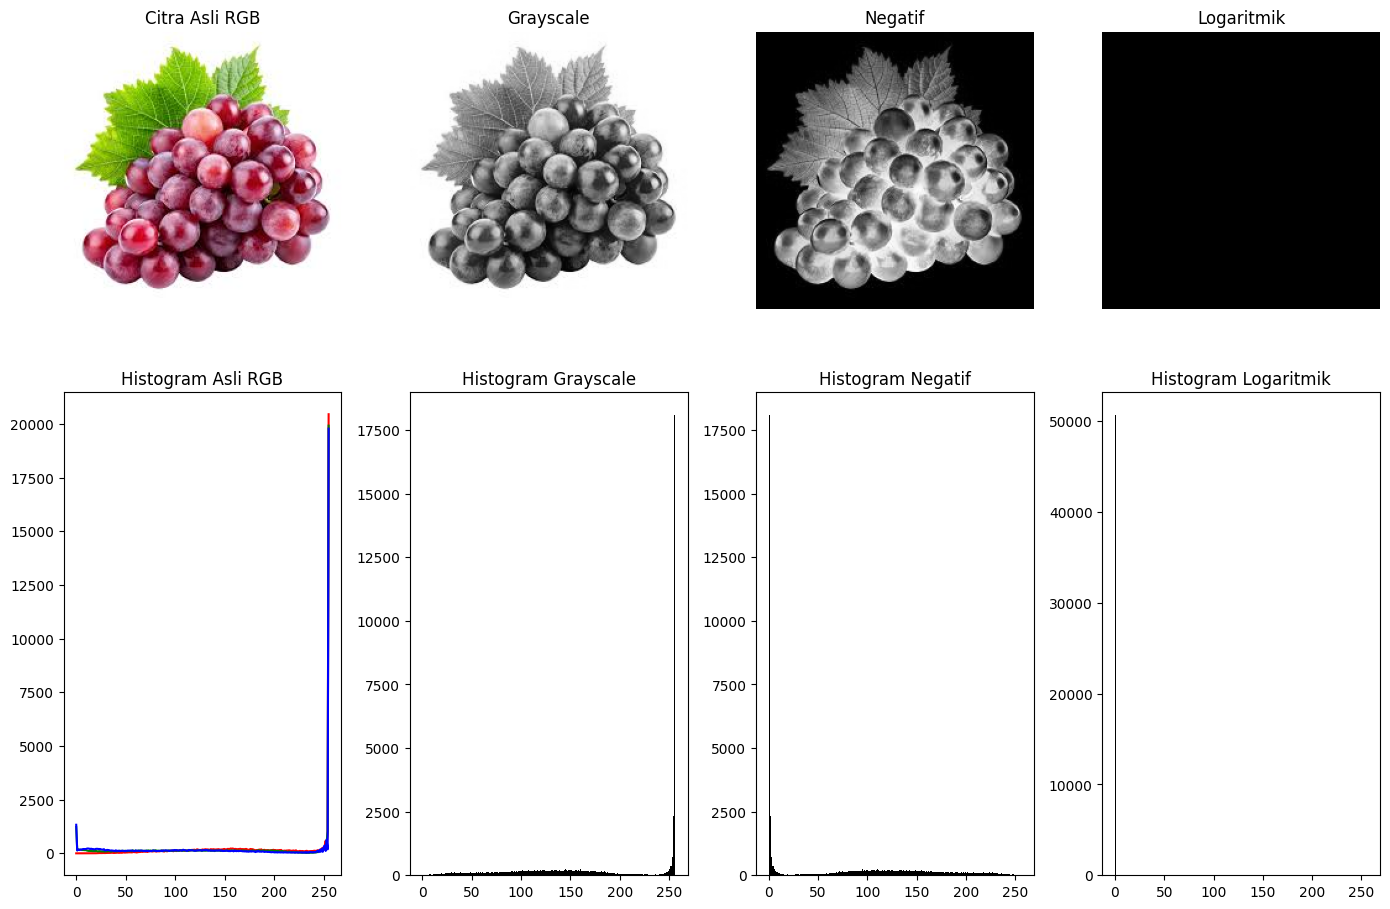

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =================================
# Membaca citra asli RGB
# =================================
img = cv2.imread('/content/images.jpg')   # ganti dengan nama file anda
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# =================================
# Konversi ke grayscale
# =================================
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# =================================
# Transformasi Negatif
# G = 255 - F
# =================================
negative = 255 - gray

# =================================
# Transformasi Logaritmik
# G = c log(1+F)
# =================================
c = 255 / np.log(1 + np.max(gray))

log_img = c * np.log(1 + gray.astype(np.float64))
log_img = np.array(log_img, dtype=np.uint8)

# =================================
# MENAMPILKAN 4 CITRA
# =================================
plt.figure(figsize=(14,10))

# Citra Asli
plt.subplot(2,4,1)
plt.imshow(img_rgb)
plt.title("Citra Asli RGB")
plt.axis('off')

# Grayscale
plt.subplot(2,4,2)
plt.imshow(gray,cmap='gray')
plt.title("Grayscale")
plt.axis('off')

# Negatif
plt.subplot(2,4,3)
plt.imshow(negative,cmap='gray')
plt.title("Negatif")
plt.axis('off')

# Logaritmik
plt.subplot(2,4,4)
plt.imshow(log_img,cmap='gray')
plt.title("Logaritmik")
plt.axis('off')

# =================================
# HISTOGRAM MASING-MASING
# =================================

# Histogram Citra Asli (RGB)
plt.subplot(2,4,5)
colors=('r','g','b')
for i,color in enumerate(colors):
    hist=cv2.calcHist([img_rgb],[i],None,[256],[0,256])
    plt.plot(hist,color=color)
plt.title("Histogram Asli RGB")

# Histogram Grayscale
plt.subplot(2,4,6)
plt.hist(gray.ravel(),256,[0,256],color='black')
plt.title("Histogram Grayscale")

# Histogram Negatif
plt.subplot(2,4,7)
plt.hist(negative.ravel(),256,[0,256],color='black')
plt.title("Histogram Negatif")

# Histogram Logaritmik
plt.subplot(2,4,8)
plt.hist(log_img.ravel(),256,[0,256],color='black')
plt.title("Histogram Logaritmik")

plt.tight_layout()
plt.show()